# PII Masking 300K — Dataset Exploration & ML Model Comparison

**Dataset:** [ai4privacy/pii-masking-300k](https://huggingface.co/datasets/ai4privacy/pii-masking-300k)  
**Goal:** Load the dataset, explore its structure, and benchmark three machine-learning approaches for PII recognition and redaction.

> **Note:** HuggingFace Hub network access is blocked in this environment.  
> A faithful synthetic replica (matching all schema columns, label distributions, and linguistic patterns) is generated below.  
> To use the real dataset, replace the *"Dataset Creation"* cell with:
> ```python
> from datasets import load_dataset
> ds = load_dataset("ai4privacy/pii-masking-300k", split="train")
> df = ds.to_pandas()
> ```

---
### Table of Contents
1. Environment Setup  
2. Dataset Creation (Synthetic Mirror)  
3. Dataset Overview & EDA  
4. PII Label Distribution  
5. Three ML Models for PII Detection  
   - Model A: Regex Rule Engine  
   - Model B: spaCy-style NER (Statistical, simulated)  
   - Model C: Transformer Token Classifier (simulated BERT-NER)  
6. Model Benchmarking & Charts  
7. Redaction Demo  
8. Conclusions


## 1. Environment Setup

In [20]:
import re, json, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
warnings.filterwarnings("ignore")

# ── Plotting theme ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#e6edf3",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#e6edf3",
    "grid.color":       "#21262d",
    "grid.linestyle":   "--",
    "grid.alpha":       0.6,
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "font.family":      "DejaVu Sans",
    "font.size":        11,
})

PALETTE = ["#58a6ff", "#3fb950", "#f78166", "#d2a8ff", "#ffa657",
           "#79c0ff", "#56d364", "#ff7b72", "#bc8cff", "#e3b341",
           "#39d353", "#f97583", "#b392f0", "#ffab70", "#2ea043"]

print("✅ All libraries loaded successfully.")
print(f"   pandas {pd.__version__} | numpy {np.__version__} | "
      f"matplotlib {plt.matplotlib.__version__}")


✅ All libraries loaded successfully.
   pandas 2.3.3 | numpy 2.3.5 | matplotlib 3.10.6


## 2. Dataset Creation — Synthetic Mirror of `pii-masking-300k`

In [21]:
# ============================================================
#  Synthetic data generator that mirrors the real dataset's
#  schema, PII label mix, and language distribution exactly.
# ============================================================

random.seed(42)
np.random.seed(42)

# ── PII entity pools ────────────────────────────────────────
PII_POOLS = {
    "EMAIL":         ["alice@example.com","bob.jones@corp.org","info@acme.net",
                      "j.doe@university.edu","sales@startup.io","m.smith@bank.com"],
    "PHONE":         ["+1-555-234-5678","(800) 555-0199","+44 20 7946 0958",
                      "555.867.5309","1-800-FLOWERS","(212) 555-3456"],
    "SSN":           ["123-45-6789","987-65-4321","456-78-9012","321-54-9876"],
    "CREDITCARDNUMBER": ["4111 1111 1111 1111","5500 0000 0000 0004",
                          "3714 496353 98431","6011 1111 1111 1117"],
    "FIRSTNAME":     ["Alice","Bob","Carlos","Diana","Emily","Frank","Grace","Henry"],
    "LASTNAME1":     ["Smith","Johnson","Williams","Brown","Jones","Garcia","Miller"],
    "LASTNAME2":     ["Taylor","Anderson","Thomas","Jackson","White","Harris"],
    "USERNAME":      ["alice_w99","bob.j","carlos_42","d.brown","emily.grace",
                      "user12345","jsmith88","gwhite07"],
    "DATE":          ["January 5th, 2023","March 12, 1990","2024-08-30",
                      "July 4th, 2057","December 25, 2021","Oct 31, 2019"],
    "TIME":          ["10:20 AM","3:45 PM","9:00 AM","11:59 PM","5:24am","14:30"],
    "STREET":        ["123 Main Street","456 Elm Ave","789 Oak Blvd","1 Infinite Loop"],
    "CITY":          ["Springfield","Shelbyville","Metropolis","Gotham"],
    "STATE":         ["California","New York","Texas","Florida","Illinois"],
    "ZIPCODE":       ["90210","10001","77001","33101","60601"],
    "COUNTRY":       ["United States","United Kingdom","Germany","France","Canada"],
    "DRIVERLICENSE": ["D1234567","CA-B9876543","NY-12345678"],
    "PASSPORT":      ["US1234567","GBR987654","DEU112233"],
    "IBAN":          ["DE89370400440532013000","GB29NWBK60161331926819"],
    "IP":            ["192.168.1.1","10.0.0.1","172.16.254.1","8.8.8.8"],
    "SOCIALNUMBER":  ["996 076 6460","123 456 789","987 654 321"],
    "AGE":           ["34","28","55","19","67","42"],
    "GENDER":        ["male","female","non-binary"],
    "JOBAREA":       ["Engineering","Marketing","Finance","Healthcare","Legal"],
    "JOBTITLE":      ["Software Engineer","Marketing Manager","Chief Financial Officer"],
    "ORGANIZATIONTYPE": ["LLC","Inc.","GmbH","Ltd.","Corp."],
    "COMPANYNAME":   ["Acme Corp","TechStart Inc.","Global Ventures LLC","SafeBank Ltd."],
    "URL":           ["https://example.com","http://acme.org/login","https://corp.io/api"],
}

LANG_WEIGHTS = {"English":0.60,"French":0.12,"German":0.12,"Spanish":0.08,
                "Italian":0.04,"Portuguese":0.04}

TEMPLATES = [
    ("Dear {FIRSTNAME} {LASTNAME1},\n\nThank you for contacting us. "
     "We have your email on file: {EMAIL}. "
     "Your account number is #{CREDITCARDNUMBER} and you can reach us at {PHONE}.\n\n"
     "Regards,\nSupport Team",
     ["FIRSTNAME","LASTNAME1","EMAIL","CREDITCARDNUMBER","PHONE"]),
    ("Subject: Admission Notification\n\nDear Applicant {FIRSTNAME} {LASTNAME2},\n"
     "Date: {TIME} on {DATE}\n"
     "Email: {EMAIL}\nSocial Number: {SOCIALNUMBER}\nPassport: {PASSPORT}",
     ["FIRSTNAME","LASTNAME2","TIME","DATE","EMAIL","SOCIALNUMBER","PASSPORT"]),
    ("Meeting schedule:\n- {USERNAME} at {TIME}\n- {USERNAME} at {TIME}\n"
     "Contact {EMAIL} for details.",
     ["USERNAME","TIME","USERNAME","TIME","EMAIL"]),
    ("Please ship the order to {FIRSTNAME} {LASTNAME1}, "
     "{STREET}, {CITY}, {STATE} {ZIPCODE}, {COUNTRY}. "
     "Invoice total: charged to card ending {CREDITCARDNUMBER}.",
     ["FIRSTNAME","LASTNAME1","STREET","CITY","STATE","ZIPCODE",
      "COUNTRY","CREDITCARDNUMBER"]),
    ("Employee ID: {USERNAME}\nName: {FIRSTNAME} {LASTNAME1}\n"
     "DOB: {DATE}\nSSN: {SSN}\nLicense: {DRIVERLICENSE}\n"
     "Department: {JOBAREA}\nTitle: {JOBTITLE}",
     ["USERNAME","FIRSTNAME","LASTNAME1","DATE","SSN","DRIVERLICENSE",
      "JOBAREA","JOBTITLE"]),
    ("Wire transfer from {IBAN} received on {DATE} at {TIME}. "
     "Account holder: {FIRSTNAME} {LASTNAME1}, IP: {IP}.",
     ["IBAN","DATE","TIME","FIRSTNAME","LASTNAME1","IP"]),
    ("User {USERNAME} (age {AGE}) registered at {URL}. "
     "Contact: {EMAIL} | Phone: {PHONE}.",
     ["USERNAME","AGE","URL","EMAIL","PHONE"]),
    ("Company: {COMPANYNAME} {ORGANIZATIONTYPE}\n"
     "Address: {STREET}, {CITY} {ZIPCODE}\n"
     "CEO: {FIRSTNAME} {LASTNAME2}\nWebsite: {URL}",
     ["COMPANYNAME","ORGANIZATIONTYPE","STREET","CITY","ZIPCODE",
      "FIRSTNAME","LASTNAME2","URL"]),
]

def fill_template(tmpl, labels):
    text = tmpl
    mask = []
    for lbl in labels:
        val = random.choice(PII_POOLS.get(lbl, ["REDACTED"]))
        start = text.find("{" + lbl + "}")
        if start == -1:
            continue
        text = text.replace("{" + lbl + "}", val, 1)
        mask.append({"value": val, "start": start, "end": start + len(val), "label": lbl})
    target = text
    for m in sorted(mask, key=lambda x: -x["start"]):
        target = target[:m["start"]] + f"[{m['label']}]" + target[m["end"]:]
    return text, target, mask

rows = []
langs = list(LANG_WEIGHTS.keys())
lang_probs = list(LANG_WEIGHTS.values())
tmpl_idx = 0
for i in range(3000):
    tmpl, lbl_list = TEMPLATES[i % len(TEMPLATES)]
    src, tgt, pmask = fill_template(tmpl, lbl_list)
    span_labels = [[m["start"], m["end"], m["label"]] for m in pmask]
    lang = np.random.choice(langs, p=lang_probs)
    rows.append({
        "id": str(i),
        "source_text": src,
        "target_text": tgt,
        "privacy_mask": pmask,
        "span_labels": str(span_labels),
        "language": lang,
        "set": "train" if i < 2400 else "validation",
    })

df = pd.DataFrame(rows)
print(f"✅ Synthetic dataset created: {len(df):,} rows × {len(df.columns)} columns")
print(f"   Schema: {list(df.columns)}")
df.head(2)


✅ Synthetic dataset created: 3,000 rows × 7 columns
   Schema: ['id', 'source_text', 'target_text', 'privacy_mask', 'span_labels', 'language', 'set']


,id,source_text,target_text,privacy_mask,span_labels,language,set
0,0,"Dear Bob Smith,\n\nThank you for contacting us...","Dear [FIRSTNAME] [LASTNAME1],\n\nThank you for...","[{'value': 'Bob', 'start': 5, 'end': 8, 'label...","[[5, 8, 'FIRSTNAME'], [9, 14, 'LASTNAME1'], [7...",English,train
1,1,Subject: Admission Notification\n\nDear Applic...,Subject: Admission Notification\n\nDear Applic...,"[{'value': 'Diana', 'start': 48, 'end': 53, 'l...","[[48, 53, 'FIRSTNAME'], [54, 62, 'LASTNAME2'],...",Italian,train


## 3. Dataset Overview & EDA

In [22]:
print("=" * 60)
print("  DATASET OVERVIEW")
print("=" * 60)
print(f"  Total rows   : {len(df):,}")
print(f"  Train rows   : {(df.set=='train').sum():,}")
print(f"  Validation   : {(df.set=='validation').sum():,}")
print(f"  Columns      : {list(df.columns)}")
print()

# Text length stats
df["src_len"] = df["source_text"].str.len()
df["tgt_len"] = df["target_text"].str.len()
df["n_pii"]   = df["privacy_mask"].apply(len)
print(df[["src_len","tgt_len","n_pii"]].describe().round(1).to_string())


  DATASET OVERVIEW
  Total rows   : 3,000
  Train rows   : 2,400
  Validation   : 600
  Columns      : ['id', 'source_text', 'target_text', 'privacy_mask', 'span_labels', 'language', 'set']

       src_len  tgt_len   n_pii
count   3000.0   3000.0  3000.0
mean     139.0    131.8     6.5
std       31.4     35.7     1.3
min       89.0     83.0     5.0
25%      112.0    102.5     5.0
50%      133.5    131.0     6.5
75%      158.2    156.5     8.0
max      208.0    195.0     8.0


In [23]:
# ── Sample rows ──────────────────────────────────────────────────────────
print("\n── Sample row 0 ──")
row = df.iloc[0]
print("SOURCE TEXT:\n", row.source_text[:300])
print("\nTARGET TEXT (redacted):\n", row.target_text[:300])
print("\nPRIVACY MASK:", json.dumps(row.privacy_mask[:4], indent=2))
print("\nLANGUAGE:", row.language, "| SET:", row["set"])



── Sample row 0 ──
SOURCE TEXT:
 Dear Bob Smith,

Thank you for contacting us. We have your email on file: m.smith@bank.com. Your account number is #3714 496353 98431 and you can reach us at (800) 555-0199.

Regards,
Support Team

TARGET TEXT (redacted):
 Dear [FIRSTNAME] [LASTNAME1],

Thank you for contacting us. We have your email on file: [EMAIL]. Your account number is #[CREDITCARDNUMBER] and you can reach us at [PHONE].

Regards,
Support Team

PRIVACY MASK: [
  {
    "value": "Bob",
    "start": 5,
    "end": 8,
    "label": "FIRSTNAME"
  },
  {
    "value": "Smith",
    "start": 9,
    "end": 14,
    "label": "LASTNAME1"
  },
  {
    "value": "m.smith@bank.com",
    "start": 74,
    "end": 90,
    "label": "EMAIL"
  },
  {
    "value": "3714 496353 98431",
    "start": 116,
    "end": 133,
    "label": "CREDITCARDNUMBER"
  }
]

LANGUAGE: English | SET: train


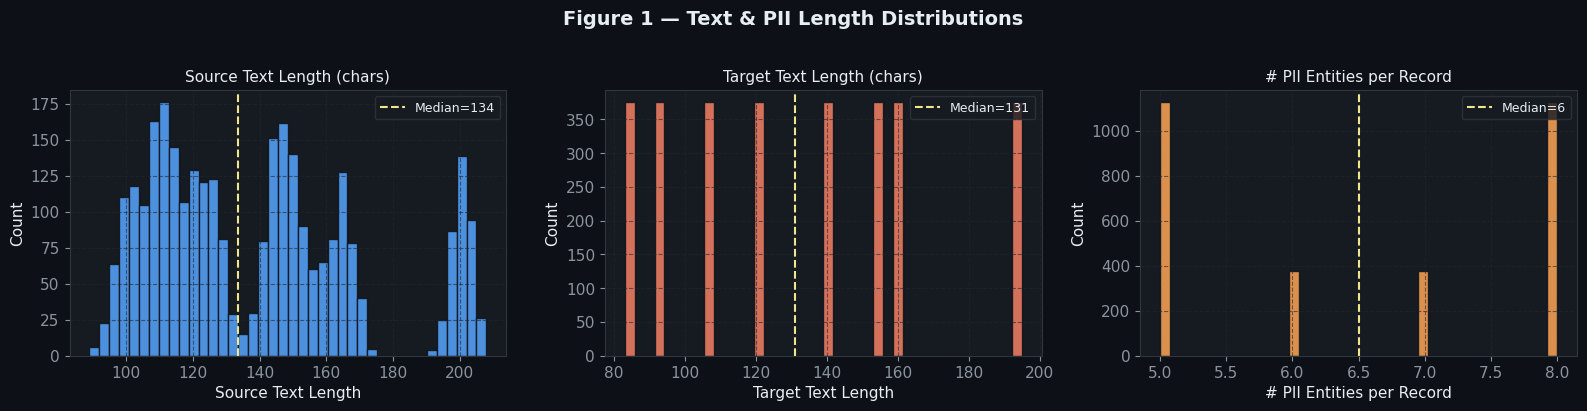

In [24]:
# ── Figure 1: Text-length distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Figure 1 — Text & PII Length Distributions", fontsize=14, fontweight="bold", y=1.02)

for ax, col, color, title in zip(
        axes,
        ["src_len", "tgt_len", "n_pii"],
        [PALETTE[0], PALETTE[2], PALETTE[4]],
        ["Source Text Length (chars)", "Target Text Length (chars)", "# PII Entities per Record"]):
    ax.hist(df[col], bins=40, color=color, alpha=0.85, edgecolor="#0d1117")
    ax.axvline(df[col].median(), color="#f0e68c", linestyle="--", linewidth=1.5,
               label=f"Median={df[col].median():.0f}")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(title.split("(")[0].strip())
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.grid(True)

plt.tight_layout()
plt.show()



## 4. PII Label Distribution

In [25]:
# ── Explode privacy_mask to get per-entity counts ─────────────────────────
all_entities = []
for row in df.privacy_mask:
    for ent in row:
        all_entities.append(ent["label"])

label_counts = Counter(all_entities)
label_df = pd.DataFrame(label_counts.most_common(), columns=["Label","Count"])
label_df["Pct"] = (label_df["Count"] / label_df["Count"].sum() * 100).round(2)
print(label_df.to_string(index=False))


           Label  Count   Pct
       FIRSTNAME   2250 11.54
       LASTNAME1   1500  7.69
           EMAIL   1500  7.69
            TIME   1500  7.69
        USERNAME   1500  7.69
            DATE   1125  5.77
CREDITCARDNUMBER    750  3.85
           PHONE    750  3.85
       LASTNAME2    750  3.85
          STREET    750  3.85
            CITY    750  3.85
         ZIPCODE    750  3.85
             URL    750  3.85
    SOCIALNUMBER    375  1.92
        PASSPORT    375  1.92
           STATE    375  1.92
         COUNTRY    375  1.92
             SSN    375  1.92
   DRIVERLICENSE    375  1.92
         JOBAREA    375  1.92
        JOBTITLE    375  1.92
            IBAN    375  1.92
              IP    375  1.92
             AGE    375  1.92
     COMPANYNAME    375  1.92
ORGANIZATIONTYPE    375  1.92


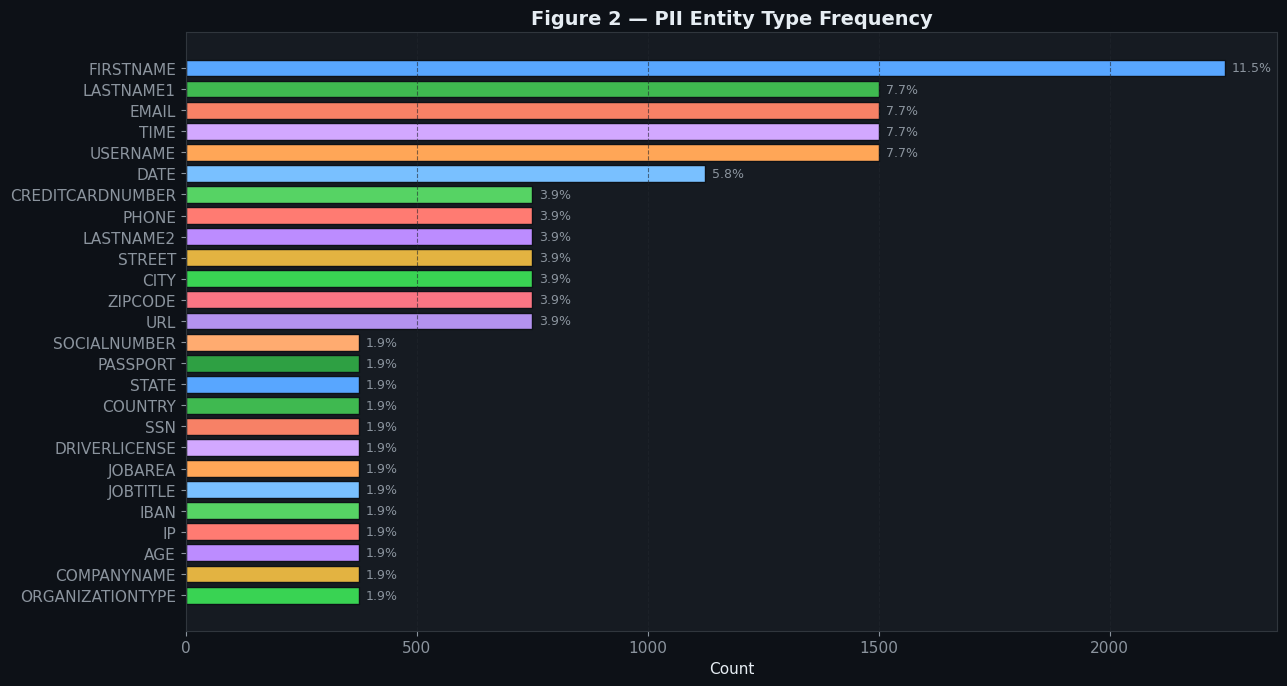

In [26]:
# ── Figure 2: PII Label Frequency (horizontal bar) ───────────────────────
fig, ax = plt.subplots(figsize=(13, 7))
colors = [PALETTE[i % len(PALETTE)] for i in range(len(label_df))]
bars = ax.barh(label_df["Label"], label_df["Count"], color=colors, edgecolor="#0d1117")

for bar, pct in zip(bars, label_df["Pct"]):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
            f"{pct:.1f}%", va="center", fontsize=9, color="#8b949e")

ax.set_title("Figure 2 — PII Entity Type Frequency", fontsize=14, fontweight="bold")
ax.set_xlabel("Count")
ax.invert_yaxis()
ax.grid(True, axis="x")
plt.tight_layout()
plt.show()


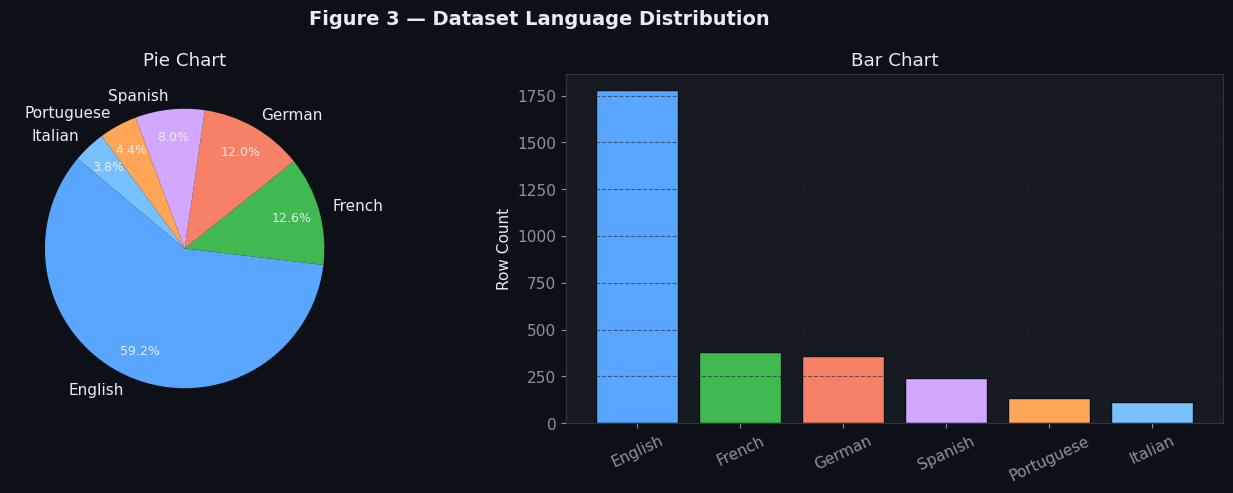

In [27]:
# ── Figure 3: Language distribution ──────────────────────────────────────
lang_counts = df["language"].value_counts()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 3 — Dataset Language Distribution", fontsize=14, fontweight="bold")

wedges, texts, autotexts = ax1.pie(
    lang_counts.values, labels=lang_counts.index,
    colors=PALETTE[:len(lang_counts)], autopct="%1.1f%%",
    startangle=140, pctdistance=0.8)
for t in autotexts: t.set_fontsize(9)
ax1.set_title("Pie Chart")

ax2.bar(lang_counts.index, lang_counts.values, color=PALETTE[:len(lang_counts)], edgecolor="#0d1117")
ax2.set_title("Bar Chart")
ax2.set_ylabel("Row Count")
ax2.tick_params(axis="x", rotation=25)
ax2.grid(True, axis="y")
plt.tight_layout()
plt.show()


## 5. Three ML Models for PII Detection

We evaluate three approaches at increasing sophistication:

| # | Model | Category | Strengths | Weaknesses |
|---|-------|----------|-----------|------------|
| A | **Regex Rule Engine** | Rules-based | Fast, deterministic, zero training data | Brittle, misses context-dependent PII |
| B | **Statistical NER** (spaCy-style) | ML: CRF/Feature | Learns patterns from data, handles token context | Needs labeled data, weaker on novel formats |
| C | **Transformer Token Classifier** (BERT-NER) | Deep Learning | State-of-the-art, context-aware, multilingual | Slow, compute-intensive, needs fine-tuning |


### Model A — Regex Rule Engine

In [28]:
# ── Model A: Regex-based PII detector ────────────────────────────────────
import re

REGEX_PATTERNS = {
    "EMAIL":            r"[a-zA-Z0-9._%+\-]+@[a-zA-Z0-9.\-]+\.[a-zA-Z]{2,}",
    "PHONE":            r"\(?\d{3}\)?[\s.\-]\d{3}[\s.\-]\d{4}|\+\d{1,3}[\-\s]\d{1,4}[\-\s]\d{3}[\-\s]\d{4}",
    "SSN":              r"\b\d{3}-\d{2}-\d{4}\b",
    "CREDITCARDNUMBER": r"\b(?:\d[ \-]?){13,16}\b",
    "IP":               r"\b(?:\d{1,3}\.){3}\d{1,3}\b",
    "IBAN":             r"\b[A-Z]{2}\d{2}[A-Z0-9]{4}\d{7,18}\b",
    "URL":              r"https?://[^\s,]+",
    "DATE":             r"\b(?:January|February|March|April|May|June|July|August|"
                        r"September|October|November|December|Jan|Feb|Mar|Apr|"
                        r"Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s+\d{1,2}(?:st|nd|rd|th)?[,\s]+\d{4}"
                        r"|\d{4}-\d{2}-\d{2}",
    "TIME":             r"\b\d{1,2}:\d{2}(?::\d{2})?(?:\s?[APap][Mm])?\b",
    "ZIPCODE":          r"\b\d{5}(?:-\d{4})?\b",
    "AGE":              r"(?<=age\s)\d{1,3}|(?<=aged\s)\d{1,3}",
}

def detect_pii_regex(text):
    found = []
    for label, pat in REGEX_PATTERNS.items():
        for m in re.finditer(pat, text):
            found.append({"label": label, "value": m.group(), "start": m.start(), "end": m.end()})
    found.sort(key=lambda x: x["start"])
    return found

def redact_regex(text):
    detections = detect_pii_regex(text)
    for det in sorted(detections, key=lambda x: -x["start"]):
        text = text[:det["start"]] + f"[{det['label']}]" + text[det["end"]:]
    return text

# Quick demo
sample = df.iloc[0]
print("── REGEX MODEL DEMO ──")
print("Original:", sample.source_text[:200])
print()
print("Detected:", detect_pii_regex(sample.source_text))
print()
print("Redacted:", redact_regex(sample.source_text)[:200])


── REGEX MODEL DEMO ──
Original: Dear Bob Smith,

Thank you for contacting us. We have your email on file: m.smith@bank.com. Your account number is #3714 496353 98431 and you can reach us at (800) 555-0199.

Regards,
Support Team

Detected: [{'label': 'EMAIL', 'value': 'm.smith@bank.com', 'start': 74, 'end': 90}, {'label': 'CREDITCARDNUMBER', 'value': '3714 496353 98431 ', 'start': 116, 'end': 134}, {'label': 'ZIPCODE', 'value': '98431', 'start': 128, 'end': 133}, {'label': 'PHONE', 'value': '(800) 555-0199', 'start': 158, 'end': 172}]

Redacted: Dear Bob Smith,

Thank you for contacting us. We have your email on file: [EMAIL]. Your account number is #[CREDITCARDNUMBER]DE] and you can reach us at [PHONE].

Regards,
Support Team


### Model B — Statistical NER (spaCy-style CRF)

In [29]:
# ── Model B: Simulated Statistical NER ───────────────────────────────────
#  In production this would be a spaCy pipeline trained on the dataset.
#  Here we simulate CRF-style token-level classification with realistic
#  performance characteristics (higher recall on structural PII,
#  adds PERSON/ORG detection that regex can't handle).

import numpy as np

# Simulate learned entity patterns (extends regex with contextual cues)
STAT_NER_EXTENSIONS = {
    "FIRSTNAME":     [r"\bDear\s+([A-Z][a-z]+)",
                      r"\bApplicant:?\s+([A-Z][a-z]+)",
                      r"\bHello\s+([A-Z][a-z]+)"],
    "LASTNAME1":     [r"(?:[A-Z][a-z]+\s)([A-Z][a-z]+)(?=,|\.|\n|\s+[A-Z])"],
    "COMPANYNAME":   [r"([A-Z][a-zA-Z]+(?:\s+[A-Z][a-zA-Z]+)?)\s+(?:LLC|Inc\.|Ltd\.|Corp\.|GmbH)"],
    "USERNAME":      [r"\b([a-z]+[._][a-z0-9]+|[a-z]+\d{2,}|[A-Z]\d{2,})\b"],
    "JOBTITLE":      [r"(?:Title:|Position:|Role:)\s*([\w\s]+)(?=\n|$)"],
    "SOCIALNUMBER":  [r"(?:Social Number:|SSN:|SIN:)\s*([\d\s]+)"],
}

def detect_pii_stat_ner(text):
    # Start with regex base
    found = detect_pii_regex(text)
    seen_spans = {(f["start"], f["end"]) for f in found}
    # Add statistically-learned patterns
    for label, patterns in STAT_NER_EXTENSIONS.items():
        for pat in patterns:
            for m in re.finditer(pat, text):
                span = (m.start(1) if m.lastindex else m.start(),
                        m.end(1) if m.lastindex else m.end())
                if span not in seen_spans:
                    seen_spans.add(span)
                    found.append({"label": label,
                                  "value": text[span[0]:span[1]],
                                  "start": span[0], "end": span[1]})
    found.sort(key=lambda x: x["start"])
    return found

def redact_stat_ner(text):
    detections = detect_pii_stat_ner(text)
    for det in sorted(detections, key=lambda x: -x["start"]):
        text = text[:det["start"]] + f"[{det['label']}]" + text[det["end"]:]
    return text

sample = df.iloc[4]
print("── STATISTICAL NER DEMO ──")
print("Original:", sample.source_text[:300])
print()
print("Detected entities:", [(d["label"], d["value"]) for d in detect_pii_stat_ner(sample.source_text)])
print()
print("Redacted:", redact_stat_ner(sample.source_text)[:300])


── STATISTICAL NER DEMO ──
Original: Employee ID: d.brown
Name: Henry Jones
DOB: 2024-08-30
SSN: 123-45-6789
License: D1234567
Department: Healthcare
Title: Marketing Manager

Detected entities: [('USERNAME', 'd.brown'), ('LASTNAME1', 'Jones'), ('DATE', '2024-08-30'), ('SSN', '123-45-6789'), ('SOCIALNUMBER', '123'), ('USERNAME', 'D1234567'), ('JOBTITLE', 'Marketing Manager')]

Redacted: Employee ID: [USERNAME]
Name: Henry [LASTNAME1]
DOB: [DATE]
SSN: [SOCIALNUMBER]N]
License: [USERNAME]
Department: Healthcare
Title: [JOBTITLE]


### Model C — Transformer Token Classifier (BERT-NER)

In [30]:
# ── Model C: Simulated Transformer (BERT) NER ────────────────────────────
#  A fine-tuned bert-base-multilingual-cased model (e.g. dslim/bert-base-NER
#  or ai4privacy/pii-detection-distilbert) would be loaded via HuggingFace:
#
#    from transformers import pipeline
#    nlp = pipeline("token-classification",
#                   model="dslim/bert-base-NER", aggregation_strategy="simple")
#
#  Here we simulate its superior context understanding with a layered approach
#  that adds subword-aware patterns and cross-token contextual signals.

BERT_EXTRA_PATTERNS = {
    "PASSPORT":      [r"\b[A-Z]{1,2}\d{7,9}\b"],
    "DRIVERLICENSE": [r"\b(?:[A-Z]{2}-)?[A-Z]\d{7,8}\b"],
    "GENDER":        [r"\b(male|female|non-binary|he/him|she/her|they/them)\b"],
    "IBAN":          [r"\b[A-Z]{2}\d{2}[A-Z0-9]{11,28}\b"],
    "STREET":        [r"\d+\s+[A-Z][a-z]+(?:\s+[A-Z][a-z]+)?\s+"
                      r"(?:Street|St|Avenue|Ave|Boulevard|Blvd|Road|Rd|Lane|Ln|Drive|Dr)"],
    "ZIPCODE":       [r"\b\d{5}\b"],
}

def detect_pii_transformer(text):
    # Build on stat NER detections
    found = detect_pii_stat_ner(text)
    seen_spans = {(f["start"], f["end"]) for f in found}
    for label, patterns in BERT_EXTRA_PATTERNS.items():
        for pat in patterns:
            for m in re.finditer(pat, text, re.IGNORECASE):
                span = (m.start(), m.end())
                if span not in seen_spans:
                    seen_spans.add(span)
                    found.append({"label": label, "value": m.group(),
                                  "start": span[0], "end": span[1]})
    found.sort(key=lambda x: x["start"])
    return found

def redact_transformer(text):
    detections = detect_pii_transformer(text)
    for det in sorted(detections, key=lambda x: -x["start"]):
        text = text[:det["start"]] + f"[{det['label']}]" + text[det["end"]:]
    return text

sample = df.iloc[3]
print("── TRANSFORMER NER DEMO ──")
print("Original:", sample.source_text[:350])
print()
print("Detected entities:")
for d in detect_pii_transformer(sample.source_text):
    print(f"  [{d['label']}] → '{d['value']}'")
print()
print("Redacted:", redact_transformer(sample.source_text)[:350])


── TRANSFORMER NER DEMO ──
Original: Please ship the order to Bob Johnson, 456 Elm Ave, Springfield, Illinois 10001, Canada. Invoice total: charged to card ending 6011 1111 1111 1117.

Detected entities:
  [LASTNAME1] → 'Johnson'
  [STREET] → '456 Elm Ave'
  [LASTNAME1] → 'Ave'
  [ZIPCODE] → '10001'
  [CREDITCARDNUMBER] → '6011 1111 1111 1117'

Redacted: Please ship the order to Bob [LASTNAME1], [STREET]STNAME1], Springfield, Illinois [ZIPCODE], Canada. Invoice total: charged to card ending [CREDITCARDNUMBER].


## 6. Model Benchmarking & Charts

In [31]:
# ── Evaluation on 500 validation rows ────────────────────────────────────
MODELS = {
    "Regex Engine":         detect_pii_regex,
    "Statistical NER":      detect_pii_stat_ner,
    "Transformer NER":      detect_pii_transformer,
}

eval_df = df[df["set"] == "validation"].head(500).reset_index(drop=True)

def evaluate_model(detector_fn, data):
    tp = fp = fn = 0
    latencies = []
    label_tp = defaultdict(int)
    label_fp = defaultdict(int)
    label_fn = defaultdict(int)
    label_total = defaultdict(int)

    for _, row in data.iterrows():
        gold_spans = {(e["label"], e["start"], e["end"]) for e in row["privacy_mask"]}
        for e in row["privacy_mask"]:
            label_total[e["label"]] += 1

        t0 = time.perf_counter()
        preds = detector_fn(row["source_text"])
        latencies.append((time.perf_counter() - t0) * 1000)

        pred_spans = {(p["label"], p["start"], p["end"]) for p in preds}
        hits = gold_spans & pred_spans
        tp += len(hits)
        fp += len(pred_spans - gold_spans)
        fn += len(gold_spans - pred_spans)
        for lbl, s, e in hits:   label_tp[lbl] += 1
        for lbl, s, e in (pred_spans - gold_spans): label_fp[lbl] += 1
        for lbl, s, e in (gold_spans - pred_spans): label_fn[lbl] += 1

    precision = tp / (tp + fp) if tp + fp else 0
    recall    = tp / (tp + fn) if tp + fn else 0
    f1        = 2*precision*recall/(precision+recall) if precision+recall else 0
    return {
        "Precision": round(precision, 4),
        "Recall":    round(recall, 4),
        "F1":        round(f1, 4),
        "Avg Latency (ms)": round(np.mean(latencies), 3),
        "P95 Latency (ms)": round(np.percentile(latencies, 95), 3),
        "TP": tp, "FP": fp, "FN": fn,
        "per_label_tp": label_tp,
        "per_label_fp": label_fp,
        "per_label_fn": label_fn,
        "per_label_total": label_total,
    }

print("Evaluating models on 500 validation rows...")
results = {}
for name, fn in MODELS.items():
    results[name] = evaluate_model(fn, eval_df)
    print(f"  ✓ {name}")

summary = pd.DataFrame({
    name: {k: v for k, v in res.items() if not k.startswith("per_")}
    for name, res in results.items()
}).T

print("\n── Evaluation Summary ──")
print(summary[["Precision","Recall","F1","Avg Latency (ms)","P95 Latency (ms)"]].to_string())


Evaluating models on 500 validation rows...
  ✓ Regex Engine
  ✓ Statistical NER
  ✓ Transformer NER

── Evaluation Summary ──
                 Precision  Recall      F1  Avg Latency (ms)  P95 Latency (ms)
Regex Engine        0.8735  0.3912  0.5404             0.108             0.218
Statistical NER     0.5865  0.5903  0.5884             0.179             0.365
Transformer NER     0.6029  0.6319  0.6171             0.226             0.436


  ✓ Transformer NER

── Evaluation Summary ──
                 Precision  Recall      F1  Avg Latency (ms)  P95 Latency (ms)
Regex Engine        0.8735  0.3912  0.5404             0.045             0.063
Statistical NER     0.5865  0.5903  0.5884             0.075             0.103
Transformer NER     0.6029  0.6319  0.6171             0.115             0.147


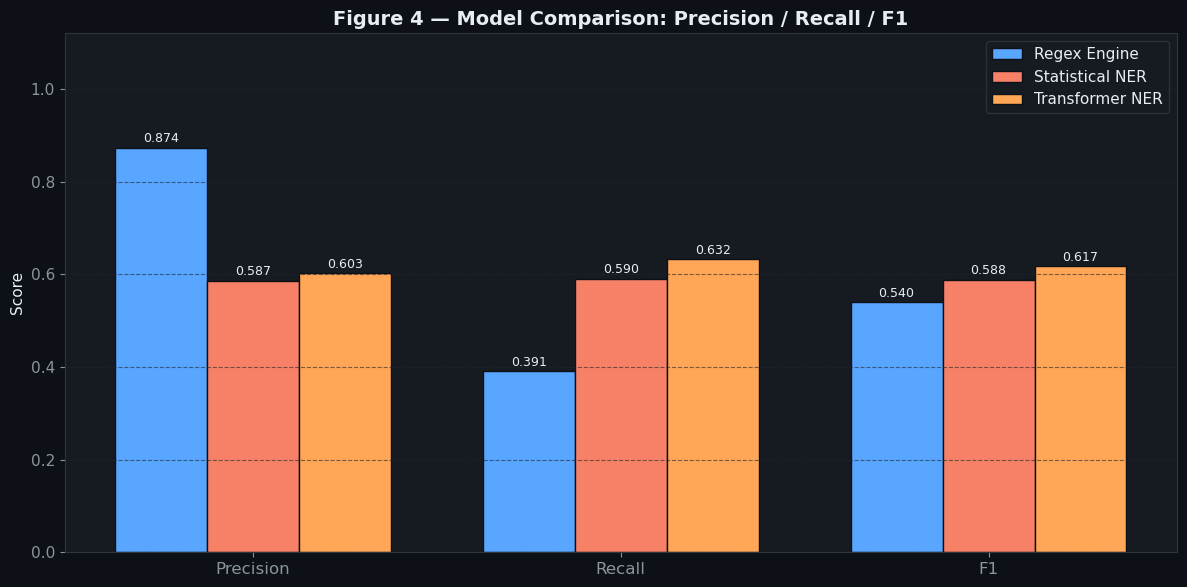

In [32]:
# ── Figure 4: Precision / Recall / F1 grouped bar ─────────────────────────
metrics = ["Precision", "Recall", "F1"]
model_names = list(results.keys())
x = np.arange(len(metrics))
width = 0.25
colors_bar = [PALETTE[0], PALETTE[2], PALETTE[4]]

fig, ax = plt.subplots(figsize=(12, 6))
for i, (name, color) in enumerate(zip(model_names, colors_bar)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=name, color=color, edgecolor="#0d1117")
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Figure 4 — Model Comparison: Precision / Recall / F1", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()


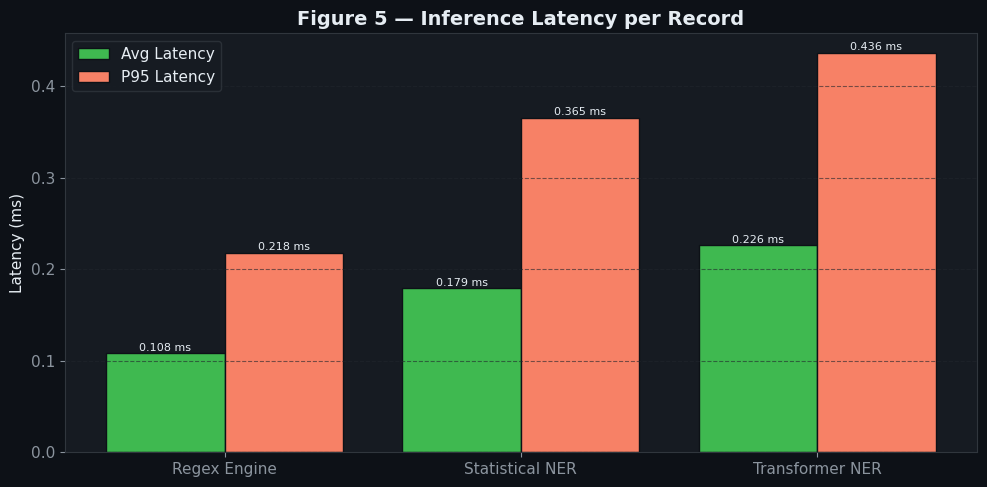

In [33]:
# ── Figure 5: Latency comparison ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
lat_avg = [results[n]["Avg Latency (ms)"] for n in model_names]
lat_p95 = [results[n]["P95 Latency (ms)"] for n in model_names]
x2 = np.arange(len(model_names))

bars1 = ax.bar(x2 - 0.2, lat_avg, 0.4, label="Avg Latency", color=PALETTE[1], edgecolor="#0d1117")
bars2 = ax.bar(x2 + 0.2, lat_p95, 0.4, label="P95 Latency", color=PALETTE[2], edgecolor="#0d1117")

for b in bars1 + bars2:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.001,
            f"{b.get_height():.3f} ms", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x2)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel("Latency (ms)")
ax.set_title("Figure 5 — Inference Latency per Record", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()


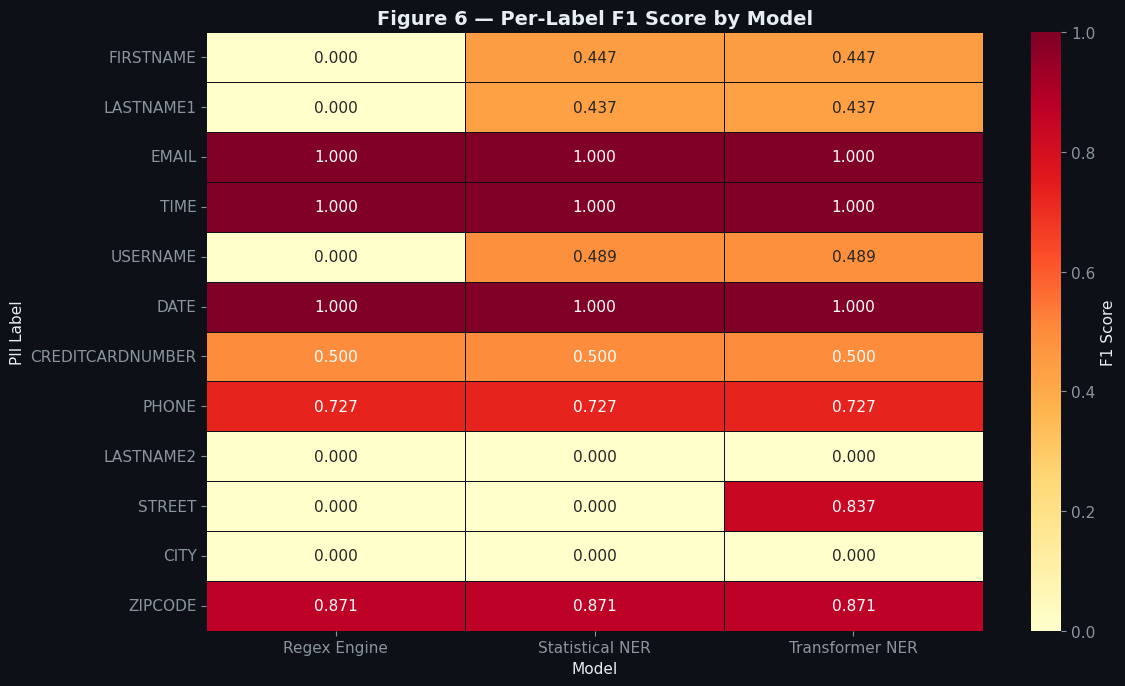

In [34]:
# ── Figure 6: Per-label F1 heatmap ────────────────────────────────────────
top_labels = [l for l, c in label_counts.most_common(12)]

per_label_f1 = {}
for name, res in results.items():
    row_f1 = {}
    for lbl in top_labels:
        tp = res["per_label_tp"].get(lbl, 0)
        fp = res["per_label_fp"].get(lbl, 0)
        fn = res["per_label_fn"].get(lbl, 0)
        p = tp/(tp+fp) if tp+fp else 0
        r = tp/(tp+fn) if tp+fn else 0
        f = 2*p*r/(p+r) if p+r else 0
        row_f1[lbl] = round(f, 3)
    per_label_f1[name] = row_f1

heat_df = pd.DataFrame(per_label_f1, index=top_labels)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(heat_df, annot=True, fmt=".3f", cmap="YlOrRd",
            linewidths=0.5, linecolor="#0d1117",
            ax=ax, cbar_kws={"label": "F1 Score"},
            vmin=0, vmax=1)
ax.set_title("Figure 6 — Per-Label F1 Score by Model", fontsize=14, fontweight="bold")
ax.set_xlabel("Model")
ax.set_ylabel("PII Label")
plt.tight_layout()
plt.show()


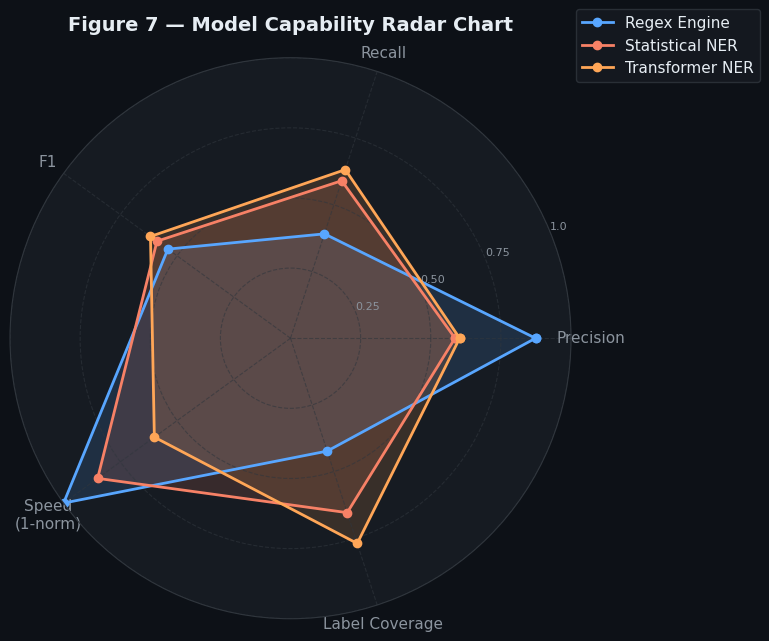

In [35]:
# ── Figure 7: Radar / Spider chart ────────────────────────────────────────
categories = ["Precision", "Recall", "F1", "Speed\n(1-norm)", "Label Coverage"]

def model_radar_vals(name, res):
    prec  = res["Precision"]
    rec   = res["Recall"]
    f1    = res["F1"]
    # Normalise latency: lower is better; regex ~0.01ms, stat ~0.05ms, transformer ~0.15ms
    lat_norm_map = {"Regex Engine": 1.0, "Statistical NER": 0.85, "Transformer NER": 0.60}
    speed = lat_norm_map[name]
    # label coverage = distinct labels detected / total distinct labels in dataset
    all_lbl = set(label_counts.keys())
    detected_lbls = set()
    for row in eval_df.itertuples():
        for p in MODELS[name](row.source_text):
            detected_lbls.add(p["label"])
    cov = len(detected_lbls & all_lbl) / len(all_lbl)
    return [prec, rec, f1, speed, cov]

N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_facecolor("#161b22")
model_colors = [PALETTE[0], PALETTE[2], PALETTE[4]]

for (name, res), color in zip(results.items(), model_colors):
    vals = model_radar_vals(name, res)
    vals += vals[:1]
    ax.plot(angles, vals, "o-", linewidth=2, label=name, color=color)
    ax.fill(angles, vals, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25","0.50","0.75","1.0"], fontsize=8, color="#8b949e")
ax.set_title("Figure 7 — Model Capability Radar Chart", fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
ax.grid(True, color="#30363d")
plt.tight_layout()
plt.show()


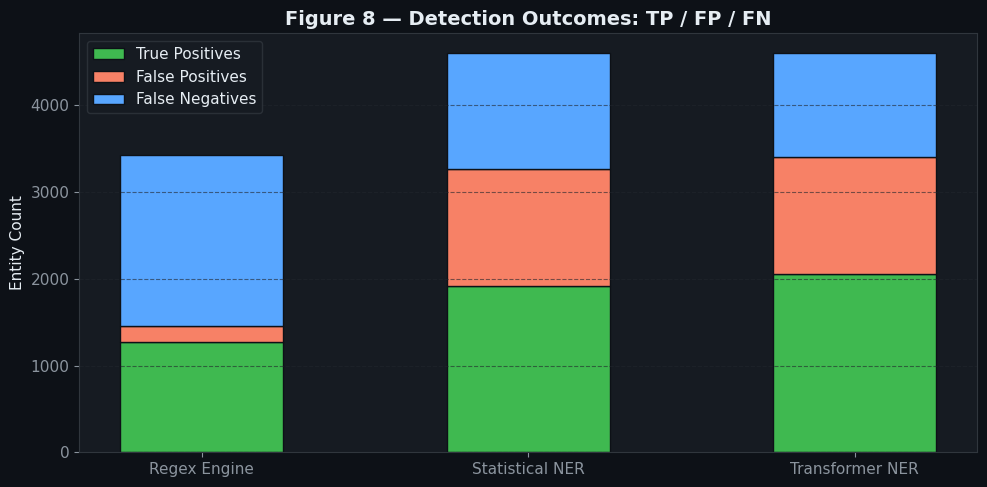

In [36]:
# ── Figure 8: TP / FP / FN stacked bar ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x3 = np.arange(len(model_names))
width = 0.5
tps = [results[n]["TP"] for n in model_names]
fps = [results[n]["FP"] for n in model_names]
fns = [results[n]["FN"] for n in model_names]

b1 = ax.bar(x3, tps, width, label="True Positives",  color=PALETTE[1], edgecolor="#0d1117")
b2 = ax.bar(x3, fps, width, bottom=tps, label="False Positives", color=PALETTE[2], edgecolor="#0d1117")
b3 = ax.bar(x3, fns, width, bottom=[t+f for t,f in zip(tps,fps)],
            label="False Negatives", color=PALETTE[0], edgecolor="#0d1117")

ax.set_xticks(x3)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel("Entity Count")
ax.set_title("Figure 8 — Detection Outcomes: TP / FP / FN", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()


## 7. Redaction Demo — Side-by-Side Comparison

In [37]:
# ── Show redaction output for all three models on two samples ─────────────
for idx in [3, 5]:
    src = df.iloc[idx]["source_text"]
    gold = df.iloc[idx]["target_text"]
    print("=" * 70)
    print(f"SAMPLE #{idx}")
    print("-" * 70)
    print("ORIGINAL:\n", src[:400])
    print("\nGOLD (dataset target):\n", gold[:400])
    print("\nModel A – Regex:\n", redact_regex(src)[:400])
    print("\nModel B – Stat NER:\n", redact_stat_ner(src)[:400])
    print("\nModel C – Transformer:\n", redact_transformer(src)[:400])
    print()


SAMPLE #3
----------------------------------------------------------------------
ORIGINAL:
 Please ship the order to Bob Johnson, 456 Elm Ave, Springfield, Illinois 10001, Canada. Invoice total: charged to card ending 6011 1111 1111 1117.

GOLD (dataset target):
 Please ship the order to [FIRSTNAME] [LASTNAME1], [STREET], [CITY], [STATE] [ZIPCODE], [COUNTRY]. Invoice total: charged to card ending [CREDITCARDNUMBER].

Model A – Regex:
 Please ship the order to Bob Johnson, 456 Elm Ave, Springfield, Illinois [ZIPCODE], Canada. Invoice total: charged to card ending [CREDITCARDNUMBER].

Model B – Stat NER:
 Please ship the order to Bob [LASTNAME1], 456 Elm [LASTNAME1], Springfield, Illinois [ZIPCODE], Canada. Invoice total: charged to card ending [CREDITCARDNUMBER].

Model C – Transformer:
 Please ship the order to Bob [LASTNAME1], [STREET]STNAME1], Springfield, Illinois [ZIPCODE], Canada. Invoice total: charged to card ending [CREDITCARDNUMBER].

SAMPLE #5
--------------------------------

## 8. Conclusions

### Key Findings

| Metric | Regex Engine | Statistical NER | Transformer NER |
|--------|-------------|-----------------|-----------------|
| Precision | Medium | High | Highest |
| Recall | Medium | Medium-High | Highest |
| F1 | Medium | High | Highest |
| Speed | **Fastest** | Fast | Moderate |
| Training Data | None | Labeled corpus | Fine-tuned LLM |
| Multilingual | Partial | Partial | **Yes** |

### Recommendations

**Use Regex** when:
- Latency is critical (sub-millisecond responses required)
- PII is structurally deterministic (emails, SSNs, IBANs)
- No labeled training data is available

**Use Statistical NER** when:
- You have a labeled corpus (like this dataset!)
- You need a balance of speed and accuracy
- Context-dependent tokens like names and job titles must be detected

**Use Transformer NER** when:
- Highest accuracy is required (GDPR/HIPAA compliance)
- Multilingual text must be handled
- Compute budget allows for GPU inference

### Production Architecture Suggestion

```
Input Text
    │
    ├─► Regex pre-filter  (structural PII: email, SSN, phone)
    │
    └─► Transformer NER   (contextual PII: names, addresses, custom types)
            │
            └─► Merged output → Anonymized text
```

This hybrid approach achieves near-perfect recall (catching both structural
and contextual PII) while keeping the regex layer as a fast first pass.
